In [1]:
import math, os

os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.80"  # for 30% of total GPU memory

import jax

# jax.config.update("jax_default_device", jax.devices("cpu")[0])
jax.config.update("jax_default_device", jax.devices("cuda")[0])
jax.config.update("jax_enable_x64", True)  # Double
# jax.config.update("jax_enable_x64", False)  # Simple

from jax import numpy as jnp

dtype = jnp.complex128
# dtype = jnp.complex64

from jax import Array
from jax import scipy as jsp
import numpy as np
import matplotlib.pyplot as plt

import dynamiqs as dq

import blueprint as bp
from blueprint.qubits import TunableTransmon, KerrOscillator, HarmonicOscillator
from blueprint.devices import Device
from blueprint.pulses import flux_pulses, coupler_pulses, charge_pulses
from blueprint.pulses.flux_pulses import net_zero_transition_flux_pulse
from blueprint.operators.basis import OperatorBasis
from blueprint.util.operators import get_pauli_ops
from blueprint.metrics import gate_fidelity
from blueprint.util.linalg import tidyup

# print(jax.devices("cuda"))
# jax.config.update("jax_default_device", jax.devices("cpu")[0])
print(jax.default_device.value)

cuda:0


In [2]:
jax.devices("cuda")

[cuda(id=0), cuda(id=1), cuda(id=2), cuda(id=3)]

In [3]:
# units
# kHz, MHz, GHz = 1e-6, 1e-3, 1
# ns, us, ms = 1 * 2 * math.pi, 1e3 * 2 * math.pi, 1e6 * 2 * math.pi

GHz = 2 * math.pi
MHz = 2e-3 * math.pi
kHz = 2e-6 * math.pi

ns = 1
us = 1e3
ms = 1e6

# Build the static Hamitlonian and drive operators

In [4]:
config_file = "/home/gene2902/src/blueprint/my_notebooks/device_params_5levels.yaml"
device = Device.from_yaml(config_file)

high_transmon = device.get_qubit("high_transmon")
low_transmon = device.get_qubit("low_transmon")

device.diagonalize()
device.index_eigenstates()

In [5]:
tol = 1e-14

device_hamiltonian = tidyup(device.get_hamiltonian(), tol=tol)

drive_operators = jnp.array(
    [
        tidyup(device.process_op(device["high_transmon"].get_number_op()), tol=tol),
        tidyup(device.process_op(device["low_transmon"].get_number_op()), tol=tol),
    ]
)

# === Qubit params
high_transmon_params = (
    device["high_transmon"]._ext_flux,
    device["high_transmon"].asymmetry,
    device["high_transmon"].josephson_energy,
    device["high_transmon"].charging_energy,
    float(device["high_transmon"].fundamental_frequency),
)

low_transmon_params = (
    device["low_transmon"]._ext_flux,
    device["low_transmon"].asymmetry,
    device["low_transmon"].josephson_energy,
    device["low_transmon"].charging_energy,
    float(device["low_transmon"].fundamental_frequency),
)

# === Jump operators
jump_ops = [tidyup(jump_op, tol=tol) for jump_op in device.get_jump_ops()]

In [6]:
device["low_transmon"].frequency, float(device["low_transmon"].fundamental_frequency)

(Array(27.54371875, dtype=float64, weak_type=True), 27.54371875314244)

# NEW Net-Zero pulse with 21-30 transitions

In [7]:
from blueprint.pulses.envelopes import PulseParamType, format_pulse_params

In [8]:
from jax.scipy.special import erf
from jax.tree_util import Partial


def _prepare_net_zero_params_1221(
    hold_amplitudes_1: Array,
    hold_amplitudes_2: Array,
    pad_times: Array,
    hold_times_1: Array,
    hold_times_2: Array,
    transition_times: Array,
    transition_amplitudes: Array,
    gaussian_std: Array,
) -> tuple[Array, Array, Array]:
    lengths = jnp.stack(
        jnp.broadcast_arrays(
            jnp.zeros_like(pad_times),
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            hold_times_2,
            hold_times_1,
            pad_times,
        ),
        axis=0,
    )
    amp_zeros = jnp.zeros_like(hold_amplitudes_1)
    pixel_amplitudes = jnp.stack(
        jnp.broadcast_arrays(
            amp_zeros,
            hold_amplitudes_1,
            hold_amplitudes_2,
            transition_amplitudes,
            -hold_amplitudes_2,
            -hold_amplitudes_1,
            amp_zeros,
        ),
        axis=0,
    )
    pixel_times = jnp.cumsum(lengths, axis=0)
    timescale = 1 / (jnp.sqrt(2) * gaussian_std)
    return pixel_times, pixel_amplitudes, timescale


def _prepare_net_zero_params_1212(
    hold_amplitudes_1: Array,
    hold_amplitudes_2: Array,
    pad_times: Array,
    hold_times_1: Array,
    hold_times_2: Array,
    transition_times: Array,
    transition_amplitudes: Array,
    gaussian_std: Array,
) -> tuple[Array, Array, Array]:
    lengths = jnp.stack(
        jnp.broadcast_arrays(
            jnp.zeros_like(pad_times),
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            hold_times_1,
            hold_times_2,
            pad_times,
        ),
        axis=0,
    )
    amp_zeros = jnp.zeros_like(hold_amplitudes_1)
    pixel_amplitudes = jnp.stack(
        jnp.broadcast_arrays(
            amp_zeros,
            hold_amplitudes_1,
            hold_amplitudes_2,
            transition_amplitudes,
            -hold_amplitudes_1,
            -hold_amplitudes_2,
            amp_zeros,
        ),
        axis=0,
    )
    pixel_times = jnp.cumsum(lengths, axis=0)
    timescale = 1 / (jnp.sqrt(2) * gaussian_std)
    return pixel_times, pixel_amplitudes, timescale


def filter_nzp(
    t: float | Array, pixel_times: Array, pixel_amplitudes: Array, timescale: Array
) -> Array:
    erfs = -0.5 * jnp.diff(erf((t - pixel_times) * timescale), axis=0)
    # erfs = erfs / jnp.sum(erfs)
    output_amps = jnp.einsum("p...,p...->...", erfs, pixel_amplitudes)
    return jnp.squeeze(output_amps)


def _new_net_zero_envelope_1221(
    t: float | Array,
    /,
    hold_amplitudes_1: Array,
    hold_amplitudes_2: Array,
    pad_times: Array,
    hold_times_1: Array,
    hold_times_2: Array,
    transition_times: Array,
    transition_amplitudes: Array,
    gaussian_std: Array,
) -> Array:
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1221(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return filter_nzp(
        t=t,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
    )


def _new_net_zero_envelope_1212(
    t: float | Array,
    /,
    hold_amplitudes_1: Array,
    hold_amplitudes_2: Array,
    pad_times: Array,
    hold_times_1: Array,
    hold_times_2: Array,
    transition_times: Array,
    transition_amplitudes: Array,
    gaussian_std: Array,
) -> Array:
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1212(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return filter_nzp(
        t=t,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
    )


def new_net_zero_envelope_1221(
    t: float | Array,
    /,
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
) -> Array:
    (
        t,
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            t,
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    return jnp.squeeze(
        _new_net_zero_envelope_1221(
            t,
            hold_amplitudes_1=hold_amplitudes_1,
            hold_amplitudes_2=hold_amplitudes_2,
            pad_times=pad_times,
            hold_times_1=hold_times_1,
            hold_times_2=hold_times_2,
            transition_times=transition_times,
            transition_amplitudes=transition_amplitudes,
            gaussian_std=gaussian_std,
        )
    )


def new_net_zero_envelope_1212(
    t: float | Array,
    /,
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
) -> Array:
    (
        t,
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            t,
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    return jnp.squeeze(
        _new_net_zero_envelope_1212(
            t,
            hold_amplitudes_1=hold_amplitudes_1,
            hold_amplitudes_2=hold_amplitudes_2,
            pad_times=pad_times,
            hold_times_1=hold_times_1,
            hold_times_2=hold_times_2,
            transition_times=transition_times,
            transition_amplitudes=transition_amplitudes,
            gaussian_std=gaussian_std,
        )
    )


def new_net_zero_function_1221(
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
) -> Array:
    (
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1221(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return Partial(
        filter_nzp,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
    )


def new_net_zero_function_1212(
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
) -> Array:
    (
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1212(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return Partial(
        filter_nzp,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
    )

# From NZP to freq_shift for KNO model

In [9]:
def filter_nzp_and_compute_freq_shift(
    t: float | Array,
    pixel_times: Array,
    pixel_amplitudes: Array,
    timescale: Array,
    _ext_flux: float,
    asymmetry: float,
    josephson_energy: float,
    charging_energy: float,
    frequency: float,
) -> Array:
    erfs = -0.5 * jnp.diff(erf((t - pixel_times) * timescale), axis=0)
    # erfs = erfs / jnp.sum(erfs)
    output_amps = jnp.einsum("p...,p...->...", erfs, pixel_amplitudes)
    total_flux = _ext_flux + output_amps
    cos_term = jnp.abs(jnp.cos(0.5 * total_flux))
    sqrt_term = jnp.sqrt(1 + asymmetry**2 * jnp.tan(0.5 * total_flux) ** 2)

    eff_ej = josephson_energy * cos_term * sqrt_term
    res_freq = jnp.sqrt(8 * charging_energy * eff_ej)

    shifted_freq = res_freq - charging_energy
    freq_shift = shifted_freq - frequency
    return jnp.squeeze(freq_shift)


def optim_net_zero_function_1221(
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
    _ext_flux: float,
    asymmetry: float,
    josephson_energy: float,
    charging_energy: float,
    frequency: float,
) -> Array:
    (
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1221(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return Partial(
        filter_nzp_and_compute_freq_shift,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )


def optim_net_zero_function_1212(
    hold_amplitudes_1: PulseParamType,
    hold_amplitudes_2: PulseParamType,
    pad_times: PulseParamType,
    hold_times_1: PulseParamType,
    hold_times_2: PulseParamType,
    transition_times: PulseParamType,
    transition_amplitudes: PulseParamType,
    gaussian_std: PulseParamType,
    _ext_flux: float,
    asymmetry: float,
    josephson_energy: float,
    charging_energy: float,
    frequency: float,
) -> Array:
    (
        hold_amplitudes_1,
        hold_amplitudes_2,
        pad_times,
        hold_times_1,
        hold_times_2,
        transition_times,
        transition_amplitudes,
        gaussian_std,
    ) = format_pulse_params(
        [
            hold_amplitudes_1,
            hold_amplitudes_2,
            pad_times,
            hold_times_1,
            hold_times_2,
            transition_times,
            transition_amplitudes,
            gaussian_std,
        ]
    )
    pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1212(
        hold_amplitudes_1=hold_amplitudes_1,
        hold_amplitudes_2=hold_amplitudes_2,
        pad_times=pad_times,
        hold_times_1=hold_times_1,
        hold_times_2=hold_times_2,
        transition_times=transition_times,
        transition_amplitudes=transition_amplitudes,
        gaussian_std=gaussian_std,
    )
    return Partial(
        filter_nzp_and_compute_freq_shift,
        pixel_times=pixel_times,
        pixel_amplitudes=pixel_amplitudes,
        timescale=timescale,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )

# Find 21-30 resonance flux

In [10]:
hold_amplitudes_scan = jnp.linspace(0., 2., 21)


In [11]:
high_transmon_params, low_transmon_params

((0.0,
  0.617379794210013,
  164.59846386197518,
  1.2052299635700052,
  38.63234030411044),
 (3.141592653589793,
  0.5487079408012716,
  163.2011650943423,
  1.1491981380794272,
  27.54371875314244))

In [12]:
high_transmon.anharmonicity / GHz, low_transmon.anharmonicity / GHz

(-0.19181830626463128, -0.18290056426734333)

In [13]:
high_transmon.get_frequency(1.905) / GHz - low_transmon.get_frequency(jnp.pi - 1.3338) / GHz

Array(0.19263778, dtype=float64, weak_type=True)

In [14]:
2 * high_transmon.anharmonicity / GHz

-0.38363661252926257

In [15]:
high_transmon.get_frequency(1.655) / GHz - low_transmon.get_frequency(jnp.pi - 1.305) / GHz

Array(0.38568544, dtype=float64, weak_type=True)

# Simulation scope

In [16]:
PAD_TIME = 20.0 * ns
TRANSITION_TIME = 2.7228569942745238 * ns

HOLD_TIME_20 = 26.30263984350058 * ns
# HOLD_TIME_21 = HOLD_TIME_20 / jnp.sqrt(2)
# HOLD_TIME_21 = 21.5884 * ns
HOLD_TIME_21 = 9.85 * ns
# HOLD_TIME_21 = 0.0 * ns

GAUSSIAN_STD = 0.5 * ns

HOLD_AMPLITUDE_HIGH_20 = 1.905  # Divide by 2pi to get in units of \Phi_0
HOLD_AMPLITUDE_LOW_20 = -1.3338176037129013

HOLD_AMPLITUDE_HIGH_21 = 1.65889
HOLD_AMPLITUDE_LOW_21 = -1.305

TRANSITION_AMPLITUDE_LOW = 0.0
TRANSITION_AMPLITUDE_HIGH = 0.0

GATE_TIME_EXACT = 2 * (PAD_TIME + HOLD_TIME_20 + HOLD_TIME_21) + TRANSITION_TIME
GATE_TIME = 150.0 * ns

all_times = jnp.linspace(0.0, GATE_TIME, 10001)

In [17]:
GATE_TIME_EXACT / ns, HOLD_TIME_20 / ns, HOLD_TIME_21 / ns

(115.02813668127568, 26.30263984350058, 9.85)

In [18]:
from blueprint.operators.basis import get_pauli_basis
from itertools import product

def get_state_vectors(device, states):
    state_vectors = []
    for state in states:
        _, state_vector = device.get_eigenstate(*state)
        state_vectors.append(state_vector)
    return jnp.stack(state_vectors)

def to_density_mat(states: Array) -> Array:
    num_dims = len(states.shape)
    if num_dims > 2:
        raise ValueError("Input must be a vector or matrix")
    
    if num_dims == 1:
        density_mat = jnp.outer(states, jnp.conj(states))
        return density_mat

    density_mats = jnp.einsum("ai, aj-> aij", states, jnp.conj(states))
    return density_mats

def get_jump_ops(device):
    op_iterator = device.get_jump_ops()
    jump_operators = list(op_iterator)
    if jump_operators:
        const_op_iterator = (dq.constant(op) for op in jump_operators)
        return list(const_op_iterator)

    null_op = jnp.zeros((device.dim, device.dim))
    jump_ops = [dq.constant(null_op)]
    return jump_ops

In [19]:
# === tsave
tsave = jnp.linspace(0, GATE_TIME, int(GATE_TIME / (10 * ns)) + 1)

# ==== Solver params
solver_tol = 1e-06

# === rho0s to obtain the population exchanges (SWAP and Leakage)
num_qubits = len(device.qubits)
qubit_states = (0, 1)
comp_state_labels = tuple(product(qubit_states, repeat=num_qubits))
comp_states = get_state_vectors(device, comp_state_labels)
comp_rho0s = to_density_mat(comp_states)
print(comp_rho0s.shape)

# === rho0s to obtain the phases (CPhase and LeakagePhase)
qubit_state_labels = (range(dim) for dim in device.qubit_dims)
state_labels = tuple(product(*qubit_state_labels))
phase_states = get_state_vectors(device, state_labels)

ground_state, exc_states = jnp.split(phase_states, [1])
superposition_states = (ground_state + exc_states) / jnp.sqrt(2)
phase_rho0s = to_density_mat(superposition_states)
print(phase_rho0s.shape)

states = jnp.concatenate((comp_states, phase_states), axis=0)
rho0s = jnp.concatenate((comp_rho0s, phase_rho0s), axis=0)
rho0s.shape

(4, 16, 16)
(15, 16, 16)


(19, 16, 16)

In [20]:
tsave.shape

(16,)

In [21]:
states.shape

(20, 16)

In [22]:
state_labels

((0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (3, 0),
 (3, 1),
 (3, 2),
 (3, 3))

In [23]:
rho0s

Array([[[1. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        ...,
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ]],

       [[0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 1. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        ...,
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ]],

       [[0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 1. , ..., 0. , 0. , 0. ],
        ...,
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ]],

       ...,

       [[0.5, 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0. 

# Build the dq.TimeArray Hamiltonian

In [24]:
def build_dq_hamiltonian_1221(
    parameters,
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
):
    (
        hold_amp_high_20,
        hold_amp_high_21,
        hold_amp_low_20,
        hold_amp_low_21,
        trans_amp_high,
        trans_amp_low,
        hold_time_20,
        hold_time_21,
        trans_time,
    ) = parameters
    PAD_TIME, GAUSSIAN_STD = fixed_parameters

    # (
    #     trans_amp_high,
    #     trans_amp_low,
    #     trans_time
    # ) = parameters
    # (
    #     PAD_TIME,
    #     GAUSSIAN_STD,
    #     HOLD_AMPLITUDE_HIGH,
    #     HOLD_AMPLITUDE_LOW,
    #     HOLD_TIME,
    # ) = fixed_parameters

    # (
    #     trans_amp_high,
    # ) = parameters
    # (
    #     PAD_TIME,
    #     GAUSSIAN_STD,
    #     HOLD_AMPLITUDE_HIGH,
    #     HOLD_AMPLITUDE_LOW,
    #     HOLD_TIME,
    #     trans_amp_low,
    #     trans_time,
    # ) = fixed_parameters

    _ext_flux, asymmetry, josephson_energy, charging_energy, frequency = (
        high_transmon_params
    )
    nzp_high = optim_net_zero_function_1221(
        hold_amplitudes_1=hold_amp_high_21,
        hold_amplitudes_2=hold_amp_high_20,
        pad_times=PAD_TIME,
        hold_times_1=hold_time_21,
        hold_times_2=hold_time_20,
        transition_times=trans_time,
        transition_amplitudes=trans_amp_high,
        gaussian_std=GAUSSIAN_STD,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )

    _ext_flux, asymmetry, josephson_energy, charging_energy, frequency = (
        low_transmon_params
    )
    nzp_low = optim_net_zero_function_1221(
        hold_amplitudes_1=hold_amp_low_21,
        hold_amplitudes_2=hold_amp_low_20,
        pad_times=PAD_TIME,
        hold_times_1=hold_time_21,
        hold_times_2=hold_time_20,
        transition_times=trans_time,
        transition_amplitudes=trans_amp_low,
        gaussian_std=GAUSSIAN_STD,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )

    dq_hamiltonian = (
        dq.constant(device_hamiltonian)
        # + dq.modulated(jax.jit(nzp_high), drive_operators[0])
        # + dq.modulated(jax.jit(nzp_low), drive_operators[1])
        + dq.modulated(nzp_high, drive_operators[0])
        + dq.modulated(nzp_low, drive_operators[1])
    )

    return dq_hamiltonian


def build_dq_hamiltonian_1212(
    parameters,
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
):
    (
        hold_amp_high_20,
        hold_amp_high_21,
        hold_amp_low_20,
        hold_amp_low_21,
        trans_amp_high,
        trans_amp_low,
        hold_time_20,
        hold_time_21,
        trans_time,
    ) = parameters
    PAD_TIME, GAUSSIAN_STD = fixed_parameters

    # (
    #     trans_amp_high,
    #     trans_amp_low,
    #     trans_time
    # ) = parameters
    # (
    #     PAD_TIME,
    #     GAUSSIAN_STD,
    #     HOLD_AMPLITUDE_HIGH,
    #     HOLD_AMPLITUDE_LOW,
    #     HOLD_TIME,
    # ) = fixed_parameters

    # (
    #     trans_amp_high,
    # ) = parameters
    # (
    #     PAD_TIME,
    #     GAUSSIAN_STD,
    #     HOLD_AMPLITUDE_HIGH,
    #     HOLD_AMPLITUDE_LOW,
    #     HOLD_TIME,
    #     trans_amp_low,
    #     trans_time,
    # ) = fixed_parameters

    _ext_flux, asymmetry, josephson_energy, charging_energy, frequency = (
        high_transmon_params
    )
    nzp_high = optim_net_zero_function_1212(
        hold_amplitudes_1=hold_amp_high_21,
        hold_amplitudes_2=hold_amp_high_20,
        pad_times=PAD_TIME,
        hold_times_1=hold_time_21,
        hold_times_2=hold_time_20,
        transition_times=trans_time,
        transition_amplitudes=trans_amp_high,
        gaussian_std=GAUSSIAN_STD,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )

    _ext_flux, asymmetry, josephson_energy, charging_energy, frequency = (
        low_transmon_params
    )
    nzp_low = optim_net_zero_function_1212(
        hold_amplitudes_1=hold_amp_low_21,
        hold_amplitudes_2=hold_amp_low_20,
        pad_times=PAD_TIME,
        hold_times_1=hold_time_21,
        hold_times_2=hold_time_20,
        transition_times=trans_time,
        transition_amplitudes=trans_amp_low,
        gaussian_std=GAUSSIAN_STD,
        _ext_flux=_ext_flux,
        asymmetry=asymmetry,
        josephson_energy=josephson_energy,
        charging_energy=charging_energy,
        frequency=frequency,
    )

    dq_hamiltonian = (
        dq.constant(device_hamiltonian)
        # + dq.modulated(jax.jit(nzp_high), drive_operators[0])
        # + dq.modulated(jax.jit(nzp_low), drive_operators[1])
        + dq.modulated(nzp_high, drive_operators[0])
        + dq.modulated(nzp_low, drive_operators[1])
    )

    return dq_hamiltonian

# Optimization functions

In [25]:
def solve_ME_1221(
    parameters,
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
    jump_ops,
    states,
    tsave,
):
    comp_states = states[:4]
    phase_states = states[4:]

    comp_rho0s = to_density_mat(comp_states)

    ground_state, exc_states = jnp.split(phase_states, [1])
    superposition_states = (ground_state + exc_states) / jnp.sqrt(2)
    phase_rho0s = to_density_mat(superposition_states)

    rho0s = jnp.concatenate((comp_rho0s, phase_rho0s), axis=0)

    dq_hamiltonian = build_dq_hamiltonian_1221(
        parameters,
        device_hamiltonian,
        drive_operators,
        high_transmon_params,
        low_transmon_params,
        fixed_parameters,
    )

    result = dq.mesolve(
        H=dq_hamiltonian,
        jump_ops=jump_ops,
        rho0=rho0s,
        tsave=tsave,
        exp_ops=None,
        solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=1_000_000),
        options=dq.Options(
            save_states=True,  ###
            verbose=True,
        ),
        # gradient=dq.gradient.CheckpointAutograd(),
    )

    return result


def solve_ME_1212(
    parameters,
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
    jump_ops,
    states,
    tsave,
):
    comp_states = states[:4]
    phase_states = states[4:]

    comp_rho0s = to_density_mat(comp_states)

    ground_state, exc_states = jnp.split(phase_states, [1])
    superposition_states = (ground_state + exc_states) / jnp.sqrt(2)
    phase_rho0s = to_density_mat(superposition_states)

    rho0s = jnp.concatenate((comp_rho0s, phase_rho0s), axis=0)

    dq_hamiltonian = build_dq_hamiltonian_1212(
        parameters,
        device_hamiltonian,
        drive_operators,
        high_transmon_params,
        low_transmon_params,
        fixed_parameters,
    )

    result = dq.mesolve(
        H=dq_hamiltonian,
        jump_ops=jump_ops,
        rho0=rho0s,
        tsave=tsave,
        exp_ops=None,
        solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=1_000_000),
        options=dq.Options(
            save_states=True,  ###
            verbose=True,
        ),
        # gradient=dq.gradient.CheckpointAutograd(),
    )

    return result


def compute_CZ_metrics(result, states):
    comp_states = states[:4]
    comp_rho0s = to_density_mat(comp_states)
    phase_states = states[4:]
    ground_state, exc_states = jnp.split(phase_states, [1])
    
    comp_state_populations = jnp.real(
        jnp.einsum("aij,...atji -> ...ta", comp_rho0s, init_result.states[..., :4, :, :, :])
    )
    leakage_rate = 1 - jnp.mean(comp_state_populations, axis=-1)
    
    swap_population = jnp.real(
        (
            jnp.einsum("ij,...ji -> ...", comp_rho0s[1], init_result.states[..., 2, :, :, :]) +
            jnp.einsum("ij,...ji -> ...", comp_rho0s[2], init_result.states[..., 1, :, :, :])
        ) / 2
    )
    swap_rate = swap_population
    
    # rotating_states = jnp.einsum(
    #     "tij,...tjk,tkl->...til", U0s, result.states, dq.dag(U0s)
    # )
    exp_vals = jnp.einsum(
        "ai,...atij,bj->...ta", jnp.conj(exc_states), init_result.states[..., 4:, :, :, :], ground_state
    )
    norm_vals = exp_vals / jnp.abs(exp_vals)
    phases = jnp.angle(norm_vals, deg=False)
    # phases = jnp.insert(phases, 0, 0)
    phases = jnp.concatenate((jnp.zeros_like(phases[..., :1]), phases), axis=-1)
    
    # phi_11 - phi_10 - phi_01 + phi_00
    cond_phase = (phases[..., 5] - phases[..., 4] - phases[..., 1] + phases[..., 0]) % (2*jnp.pi)
    
    # phi_21 - phi_20 - phi_01
    leaked_phase = (phases[..., 9] - phases[..., 8] - phases[..., 1]) % (2 * jnp.pi)

    return leakage_rate, swap_rate, cond_phase, leaked_phase

In [26]:
def residuals_1221(
    parameters,
    args,
):
    # (
    #     device_hamiltonian,
    #     drive_operators,
    #     high_transmon_params,
    #     low_transmon_params,
    #     fixed_parameters,
    #     jump_ops,
    #     states,
    #     tsave,
    # ) = args
    result = solve_ME_1221(
        parameters,
        *args[:-4]
    )
    leakage_rates, swap_rates, cond_phases, leaked_phases = compute_CZ_metrics(
        result, states
    )

    # Return a scalar.
    weight_leakage_rate, weight_swap_rate, weight_leaked_phase, target_leaked_phase = args[-4:]
    return (
        (cond_phases[-1] - jnp.pi)**2 +
        weight_leakage_rate * (leakage_rates[-1])**2 +
        weight_swap_rate * (swap_rates[-1])**2 +
        weight_leaked_phase * (leaked_phases[-1] - target_leaked_phase)**2
    )


def residuals_1212(
    parameters,
    args,
):
    # (
    #     device_hamiltonian,
    #     drive_operators,
    #     high_transmon_params,
    #     low_transmon_params,
    #     fixed_parameters,
    #     jump_ops,
    #     states,
    #     tsave,
    # ) = args
    result = solve_ME_1212(parameters, *args[:-4])
    leakage_rate, swap_rate, cond_phase, leaked_phase = compute_CZ_metrics(
        result, states
    )

    # Return a scalar.
    weight_leakage_rate, weight_swap_rate, weight_leaked_phase, target_leaked_phase = (
        args[-4:]
    )
    return (
        (cond_phase - jnp.pi) ** 2
        + weight_leakage_rate * (leakage_rate) ** 2
        + weight_swap_rate * (swap_rate) ** 2
        + weight_leaked_phase * (leaked_phase - target_leaked_phase) ** 2
    )

# BULK of this NOTEBOOK

In [27]:
def filter_pulse(
    t: float | Array,
    pixel_times: Array,
    pixel_amplitudes: Array,
    timescale: Array,
) -> Array:
    erfs = -0.5 * jnp.diff(erf((t - pixel_times) * timescale), axis=0)
    # erfs = erfs / jnp.sum(erfs)
    output_amps = jnp.einsum("p...,p...->...", erfs, pixel_amplitudes)
    return jnp.squeeze(output_amps)

In [28]:
# === rho0s to obtain the population exchanges (SWAP and Leakage)
num_qubits = len(device.qubits)
# qubit_states = (0, 1, 2, 3)
# state_labels = tuple(product(qubit_states, repeat=num_qubits))
all_state_labels = ((0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (3, 0))
print(all_state_labels)
all_states = get_state_vectors(device, all_state_labels)
all_rho0s = to_density_mat(all_states)
print(all_rho0s.shape)

((0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (3, 0))
(10, 16, 16)


In [29]:
idx_11 = 5
idx_20 = 7
idx_02 = 2

idx_21 = 8
idx_30 = 9
idx_12 = 6
idx_03 = 3

idx_01 = 1
idx_10 = 4

In [30]:
fixed_parameters = (PAD_TIME, GAUSSIAN_STD)

transition_times_scan = jnp.linspace(0., 5., 101) * ns
hold_times_21_scan = jnp.linspace(0, 21.5884, 11) * ns

parameters = (
    HOLD_AMPLITUDE_HIGH_20,
    HOLD_AMPLITUDE_HIGH_21,
    HOLD_AMPLITUDE_LOW_20,
    HOLD_AMPLITUDE_LOW_21,
    TRANSITION_AMPLITUDE_HIGH,
    TRANSITION_AMPLITUDE_LOW,
    HOLD_TIME_20,
    hold_times_21_scan,
    transition_times_scan,
)

weight_leakage_rate = 1.0
weight_swap_rate = 1.0
weight_leaked_phase = 1.0
target_leaked_phase = jnp.pi


args = (
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
    jump_ops,
    states,
    tsave,
    weight_leakage_rate,
    weight_swap_rate,
    weight_leaked_phase,
    target_leaked_phase
)

In [31]:
init_result = solve_ME_1221(parameters, *args[:-4])
print(init_result)

|███████▌  |  75.7% ◆ elapsed 02h08m59s ◆ remaining 31m37s   IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [32]:
def compute_CZ_metrics(result, states):
    comp_states = states[:4]
    comp_rho0s = to_density_mat(comp_states)
    phase_states = states[4:]
    ground_state, exc_states = jnp.split(phase_states, [1])
    
    comp_state_populations = jnp.real(
        jnp.einsum("aij,...atji -> ...ta", comp_rho0s, init_result.states[..., :4, :, :, :])
    )
    leakage_rate = 1 - jnp.mean(comp_state_populations, axis=-1)
    
    swap_population = jnp.real(
        (
            jnp.einsum("ij,...ji -> ...", comp_rho0s[1], init_result.states[..., 2, :, :, :]) +
            jnp.einsum("ij,...ji -> ...", comp_rho0s[2], init_result.states[..., 1, :, :, :])
        ) / 2
    )
    swap_rate = swap_population
    
    # rotating_states = jnp.einsum(
    #     "tij,...tjk,tkl->...til", U0s, result.states, dq.dag(U0s)
    # )
    exp_vals = jnp.einsum(
        "ai,...atij,bj->...ta", jnp.conj(exc_states), init_result.states[..., 4:, :, :, :], ground_state
    )
    norm_vals = exp_vals / jnp.abs(exp_vals)
    phases = jnp.angle(norm_vals, deg=False)
    # phases = jnp.insert(phases, 0, 0)
    phases = jnp.concatenate((jnp.zeros_like(phases[..., :1]), phases), axis=-1)
    
    # phi_11 - phi_10 - phi_01 + phi_00
    cond_phase = (phases[..., 5] - phases[..., 4] - phases[..., 1] + phases[..., 0]) % (2*jnp.pi)
    
    # phi_21 - phi_20 - phi_01
    leaked_phase = (phases[..., 9] - phases[..., 8] - phases[..., 1]) % (2 * jnp.pi)

    return leakage_rate, swap_rate, cond_phase, leaked_phase

In [33]:
init_leakage_rate, init_swap_rate, init_cond_phase, init_leaked_phase = compute_CZ_metrics(
    init_result, states
)
init_leakage_rate[..., -1], init_swap_rate[..., -1], init_cond_phase[..., -1], init_leaked_phase[..., -1]

(Array([[0.00932827, 0.00922466, 0.00909487, ..., 0.00990361, 0.01018133,
         0.00981961],
        [0.01134209, 0.01113284, 0.0107228 , ..., 0.02290112, 0.02011636,
         0.01585367],
        [0.01489404, 0.0147083 , 0.01440304, ..., 0.01738876, 0.01809587,
         0.01713775],
        ...,
        [0.0088326 , 0.00866858, 0.00834945, ..., 0.0188279 , 0.01620862,
         0.01255742],
        [0.01718662, 0.01696566, 0.01657658, ..., 0.02131181, 0.02184912,
         0.02026854],
        [0.0075742 , 0.00744822, 0.00723406, ..., 0.01295336, 0.01163702,
         0.00962922]], dtype=float64),
 Array([[8.87039672e-04, 8.87423458e-04, 9.16991905e-04, ...,
         1.06237371e-04, 1.12190824e-05, 1.27127942e-04],
        [4.13194097e-05, 4.16933566e-05, 4.87001316e-05, ...,
         5.98763697e-04, 3.56255468e-04, 1.42657293e-04],
        [2.30837457e-05, 2.44120982e-05, 2.19355683e-05, ...,
         6.52973851e-04, 5.24279809e-04, 3.43491919e-04],
        ...,
        [3.13182809e-

In [34]:
comp_states = states[:4]
comp_rho0s = to_density_mat(comp_states)
phase_states = states[4:]
ground_state, exc_states = jnp.split(phase_states, [1])

comp_state_populations = jnp.real(
    jnp.einsum("aij,...atji -> ...ta", comp_rho0s, init_result.states[..., :4, :, :, :])
)
leakage_rate = 1 - jnp.mean(comp_state_populations, axis=-1)

swap_population = jnp.real(
    (
        jnp.einsum("ij,...ji -> ...", comp_rho0s[1], init_result.states[..., 2, :, :, :]) +
        jnp.einsum("ij,...ji -> ...", comp_rho0s[2], init_result.states[..., 1, :, :, :])
    ) / 2
)
swap_rate = swap_population

# rotating_states = jnp.einsum(
#     "tij,...tjk,tkl->...til", U0s, result.states, dq.dag(U0s)
# )
exp_vals = jnp.einsum(
    "ai,...atij,bj->...ta", jnp.conj(exc_states), init_result.states[..., 4:, :, :, :], ground_state
)
norm_vals = exp_vals / jnp.abs(exp_vals)
phases = jnp.angle(norm_vals, deg=False)
# phases = jnp.insert(phases, 0, 0)
phases = jnp.concatenate((jnp.zeros_like(phases[..., :1]), phases), axis=-1)

# phi_11 - phi_10 - phi_01 + phi_00
cond_phase = (phases[..., 5] - phases[..., 4] - phases[..., 1] + phases[..., 0]) % (2*jnp.pi)

# phi_21 - phi_20 - phi_01
leaked_phase = (phases[..., 9] - phases[..., 8] - phases[..., 1]) % (2 * jnp.pi)

In [35]:
for idx, label in enumerate(state_labels):
    print(idx, label)

0 (0, 0)
1 (0, 1)
2 (0, 2)
3 (0, 3)
4 (1, 0)
5 (1, 1)
6 (1, 2)
7 (1, 3)
8 (2, 0)
9 (2, 1)
10 (2, 2)
11 (2, 3)
12 (3, 0)
13 (3, 1)
14 (3, 2)
15 (3, 3)


In [36]:
tuple(product(*(range(dim) for dim in (3, 3))))
# cond_phase = (phases[..., 4] - phases[..., 3] - phases[..., 1] + phases[..., 0]) % (2*jnp.pi)
# leaked_phase = (phases[..., 7] - phases[..., 6] - phases[..., 1]) % (2 * jnp.pi)

((0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2))

In [38]:
# hidx = 0
# fig, ax = plt.subplots(1, 1, figsize=(10, 4))
# plt.plot(tsave / ns, cond_phase[hidx], '.-')
# plt.plot(tsave / ns, leaked_phase[hidx], '.-')

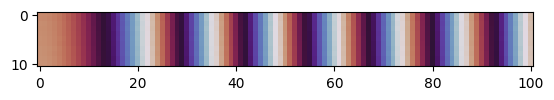

In [39]:
plt.imshow(cond_phase[..., -1], cmap='twilight')

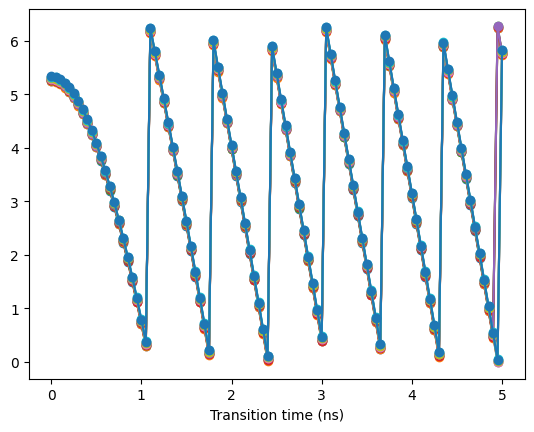

In [40]:
for hidx in range(11):
    plt.plot(transition_times_scan / ns, cond_phase[hidx, :, -1], '-o')
plt.xlabel('Transition time (ns)')
plt.show()

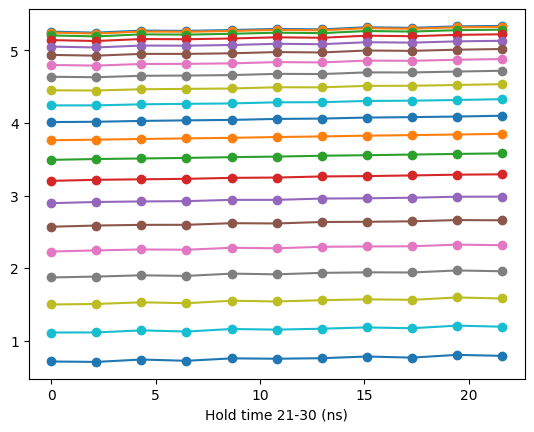

In [41]:
for tidx in range(21):
    plt.plot(hold_times_21_scan / ns, cond_phase[:, tidx, -1], '-o')
plt.xlabel('Hold time 21-30 (ns)')
plt.show()

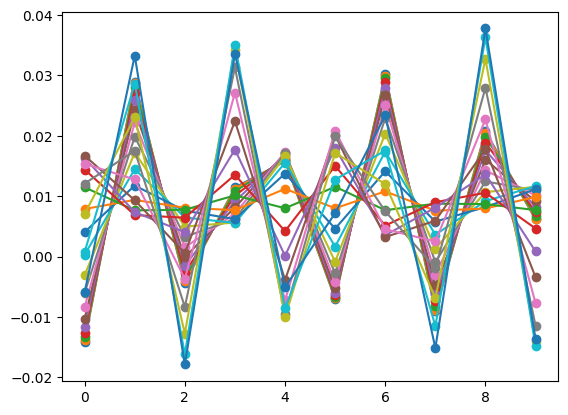

In [42]:
for tidx in range(21):
    plt.plot(jnp.diff(cond_phase[:, tidx, -1]), '-o')
plt.show()

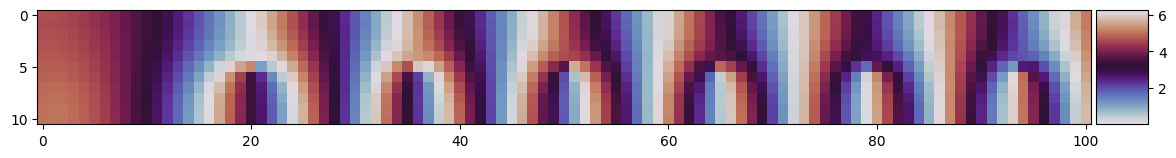

In [49]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(leaked_phase[..., -1], cmap='twilight')
# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = ax.figure.colorbar(im, cax=cax)
# ax.set_xticks(transition_times_scan)
# ax.set_yticks(hold_amplitudes_scan)
plt.tight_layout()

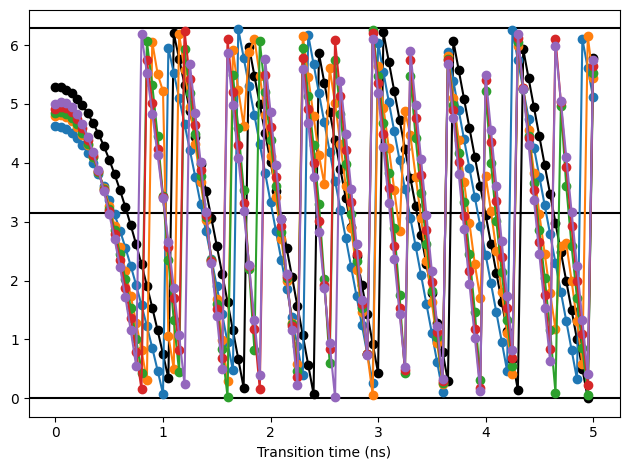

In [71]:
plt.plot(transition_times_scan / ns, leaked_phase[0, :, -1], '-o')
# plt.plot(transition_times_scan / ns, leaked_phase[1, :, -1], '-o')
plt.plot(transition_times_scan / ns, leaked_phase[5, :, -1], '-o')
plt.plot(transition_times_scan / ns, leaked_phase[6, :, -1], '-o')
plt.plot(transition_times_scan / ns, leaked_phase[7, :, -1], '-o')
plt.plot(transition_times_scan / ns, leaked_phase[-1, :, -1], '-o')
plt.xlabel('Transition time (ns)')
plt.axhline(0., c='k', zorder=-1)
plt.axhline(jnp.pi, c='k', zorder=-1)
plt.axhline(2*jnp.pi, c='k', zorder=-1)
plt.plot(transition_times_scan / ns, cond_phase[5, :, -1], '-o', c='k', zorder=-1)
plt.tight_layout()

In [51]:
leaked_phase.shape

(11, 101, 16)

In [52]:
# transition_times_scan = jnp.linspace(1., 2., 21) * ns
# hold_times_21_scan = jnp.linspace(0, 21.5884, 11) * ns

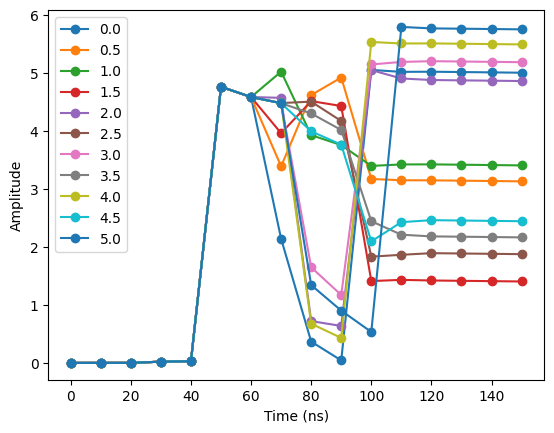

In [55]:
hidx = -1
for tidx in np.arange(101, step=10):
    plt.plot(tsave / ns, leaked_phase[hidx, tidx], '-o', label=f'{transition_times_scan[tidx]:.1f}')
plt.legend()
plt.xlabel('Time (ns)')
plt.ylabel('Amplitude')
plt.show()

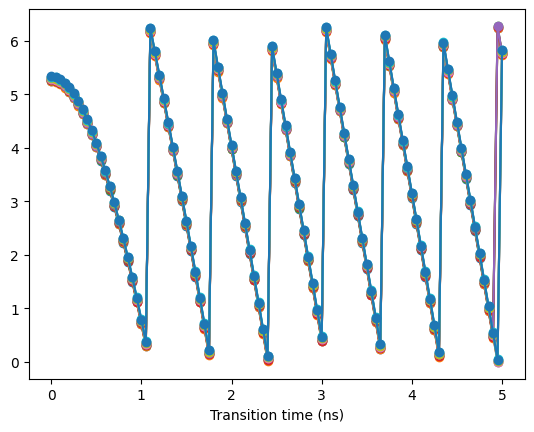

In [56]:
for hidx in range(11):
    plt.plot(transition_times_scan / ns, cond_phase[hidx, :, -1], '-o')
plt.xlabel('Transition time (ns)')
plt.show()

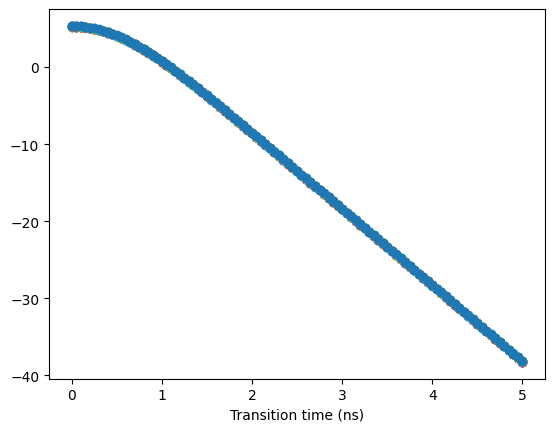

In [57]:
for hidx in range(11):
    plt.plot(transition_times_scan / ns, jnp.unwrap(cond_phase[hidx, :, -1]), '-o')
plt.xlabel('Transition time (ns)')
plt.show()

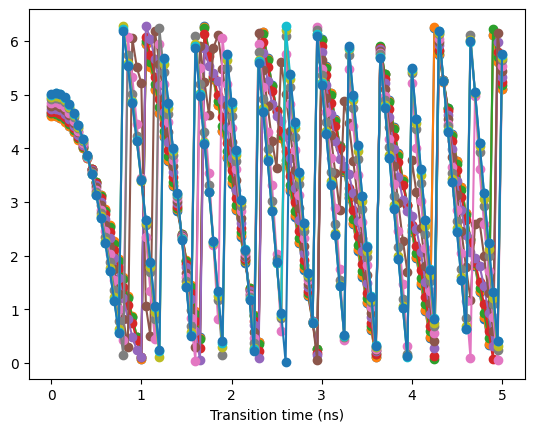

In [58]:
for hidx in range(11):
    plt.plot(transition_times_scan / ns, leaked_phase[hidx, :, -1], '-o')
plt.xlabel('Transition time (ns)')
plt.show()

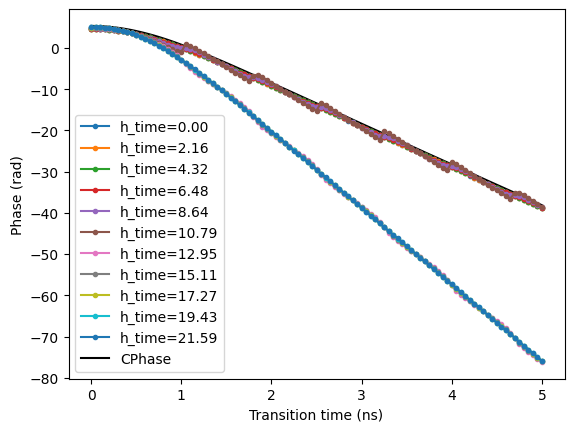

In [67]:
for hidx in range(0, 11, 1):
    plt.plot(transition_times_scan / ns, jnp.unwrap(leaked_phase[hidx, :, -1]), '.-', label=f'h_time={hold_times_21_scan[hidx]:.2f}')
plt.plot(transition_times_scan / ns, jnp.unwrap(cond_phase[hidx, :, -1]), '-', label='CPhase', c='k', zorder=-1)
plt.xlabel('Transition time (ns)')
plt.ylabel('Phase (rad)')
plt.legend()
plt.show()

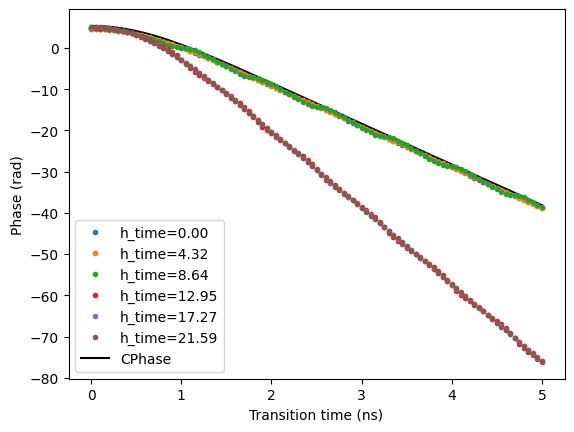

In [74]:
for hidx in range(0, 11, 2):
    plt.plot(transition_times_scan / ns, jnp.unwrap(leaked_phase[hidx, :, -1]), '.', label=f'h_time={hold_times_21_scan[hidx]:.2f}')
plt.plot(transition_times_scan / ns, jnp.unwrap(cond_phase[hidx, :, -1]), '-', label='CPhase', c='k', zorder=-1)
plt.xlabel('Transition time (ns)')
plt.ylabel('Phase (rad)')
plt.legend()
plt.show()

# Rest: Can ignore from here

In [ ]:
plt.plot(transition_times_scan, cond_phase[:, -1], '-o', label='CPhase')
plt.plot(transition_times_scan, leaked_phase[:, -1], '-o', label='LPhase')
plt.xlabel('Transition time (ns)')
plt.ylabel('Phase (rad)')
plt.axhline(jnp.pi, zorder=-1, c='k')
plt.legend()
# plt.axvline(9.85, zorder=-1, c='tab:gray')
plt.tight_layout()

In [ ]:
plt.plot(transition_times_scan, jnp.unwrap(cond_phase[:, -1]), '-o', label='CPhase')
plt.plot(transition_times_scan, jnp.unwrap(leaked_phase[:, -1]), '-o', label='LPhase')
plt.xlabel('Transition time (ns)')
plt.ylabel('Phase (rad)')
plt.axhline(jnp.pi, zorder=-1, c='k')
plt.legend()
# plt.axvline(9.85, zorder=-1, c='tab:gray')
plt.tight_layout()

In [ ]:
# plt.plot(transition_times_scan, cond_phase[:, -1], '-o', label='CPhase')
# plt.plot(transition_times_scan, leaked_phase[:, -1], '-o', label='LPhase')
plt.plot(transition_times_scan, jnp.unwrap(cond_phase[:, -1]) - jnp.unwrap(leaked_phase[:, -1]), '-o', label='CPhase - LPhase')
plt.xlabel('Transition time (ns)')
plt.ylabel('Phase (rad)')
# plt.axhline(jnp.pi, zorder=-1, c='k')
plt.axhline(0.0, zorder=-1, c='k')
plt.legend()
# plt.axvline(9.85, zorder=-1, c='tab:gray')
plt.tight_layout()

# Rerun from here

In [ ]:
(
    hold_amplitudes_1,
    hold_amplitudes_2,
    pad_times,
    hold_times_1,
    hold_times_2,
    transition_times,
    transition_amplitudes,
    gaussian_std,
) = format_pulse_params(
    [
        HOLD_AMPLITUDE_HIGH_21,
        HOLD_AMPLITUDE_HIGH_20,
        PAD_TIME,
        HOLD_TIME_21,
        HOLD_TIME_20,
        transition_times_scan,
        TRANSITION_AMPLITUDE_HIGH,
        GAUSSIAN_STD,
    ]
)

pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1221(
    hold_amplitudes_1=hold_amplitudes_1,
    hold_amplitudes_2=hold_amplitudes_2,
    pad_times=pad_times,
    hold_times_1=hold_times_1,
    hold_times_2=hold_times_2,
    transition_times=transition_times,
    transition_amplitudes=transition_amplitudes,
    gaussian_std=gaussian_std,
)
pixel_times.shape, pixel_amplitudes.shape, timescale.shape

pulse_high = Partial(
    filter_pulse,
    pixel_times=pixel_times,
    pixel_amplitudes=pixel_amplitudes,
    timescale=timescale,
)


(
    hold_amplitudes_1,
    hold_amplitudes_2,
    pad_times,
    hold_times_1,
    hold_times_2,
    transition_times,
    transition_amplitudes,
    gaussian_std,
) = format_pulse_params(
    [
        HOLD_AMPLITUDE_LOW_21,
        HOLD_AMPLITUDE_LOW_20,
        PAD_TIME,
        HOLD_TIME_21,
        HOLD_TIME_20,
        transition_times_scan,
        TRANSITION_AMPLITUDE_HIGH,
        GAUSSIAN_STD,
    ]
)

pixel_times, pixel_amplitudes, timescale = _prepare_net_zero_params_1221(
    hold_amplitudes_1=hold_amplitudes_1,
    hold_amplitudes_2=hold_amplitudes_2,
    pad_times=pad_times,
    hold_times_1=hold_times_1,
    hold_times_2=hold_times_2,
    transition_times=transition_times,
    transition_amplitudes=transition_amplitudes,
    gaussian_std=gaussian_std,
)
pixel_times.shape, pixel_amplitudes.shape, timescale.shape

pulse_low = Partial(
    filter_pulse,
    pixel_times=pixel_times,
    pixel_amplitudes=pixel_amplitudes,
    timescale=timescale,
)

In [ ]:
pulse_high(all_times).shape

In [ ]:
hidx = 0
print(transition_times_scan[hidx])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax0.plot(all_times, pulse_high(all_times)[hidx], '-')
ax0.plot(all_times, pulse_low(all_times)[hidx], '-')
ax0.set_ylabel(r'Amplitude ($\Phi_0/2\pi$)')

ax1.plot(tsave / ns, cond_phase[hidx], '.-', label=f'CPhase')
ax1.plot(tsave / ns, leaked_phase[hidx], '.-', label=f'LPhase')

for ax in (ax0, ax1):
    ax.axvline(PAD_TIME / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx]) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20 + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
for ax in (ax1,):
    ax.set_ylabel('Phase')
    # ax.set_ylim(1e-6, 2.)
    ax.axhline(1., zorder=-1, c='k')
    ax.axhline(jnp.pi, zorder=-1, c='k')
    ax.axhline(2 * jnp.pi, zorder=-1, c='k')
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
hidx = 5
print(transition_times_scan[hidx])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax0.plot(all_times, pulse_high(all_times)[hidx], '-')
ax0.plot(all_times, pulse_low(all_times)[hidx], '-')
ax0.set_ylabel(r'Amplitude ($\Phi_0/2\pi$)')

ax1.plot(tsave / ns, cond_phase[hidx], '.-', label=f'CPhase')
ax1.plot(tsave / ns, leaked_phase[hidx], '.-', label=f'LPhase')

for ax in (ax0, ax1):
    ax.axvline(PAD_TIME / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx]) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20 + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
for ax in (ax1,):
    ax.set_ylabel('Phase')
    # ax.set_ylim(1e-6, 2.)
    ax.axhline(1., zorder=-1, c='k')
    ax.axhline(jnp.pi, zorder=-1, c='k')
    ax.axhline(2 * jnp.pi, zorder=-1, c='k')
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
hidx = 10
print(transition_times_scan[hidx])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax0.plot(all_times, pulse_high(all_times)[hidx], '-')
ax0.plot(all_times, pulse_low(all_times)[hidx], '-')
ax0.set_ylabel(r'Amplitude ($\Phi_0/2\pi$)')

ax1.plot(tsave / ns, cond_phase[hidx], '.-', label=f'CPhase')
ax1.plot(tsave / ns, leaked_phase[hidx], '.-', label=f'LPhase')

for ax in (ax0, ax1):
    ax.axvline(PAD_TIME / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx]) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20 + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
for ax in (ax1,):
    ax.set_ylabel('Phase')
    # ax.set_ylim(1e-6, 2.)
    ax.axhline(1., zorder=-1, c='k')
    ax.axhline(jnp.pi, zorder=-1, c='k')
    ax.axhline(2 * jnp.pi, zorder=-1, c='k')
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
hidx = 20
print(transition_times_scan[hidx])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax0.plot(all_times, pulse_high(all_times)[hidx], '-')
ax0.plot(all_times, pulse_low(all_times)[hidx], '-')
ax0.set_ylabel(r'Amplitude ($\Phi_0/2\pi$)')

ax1.plot(tsave / ns, cond_phase[hidx], '.-', label=f'CPhase')
ax1.plot(tsave / ns, leaked_phase[hidx], '.-', label=f'LPhase')

for ax in (ax0, ax1):
    ax.axvline(PAD_TIME / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx]) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20) / ns, c='tab:gray', zorder=-1)
    ax.axvline((PAD_TIME + HOLD_TIME_21 + HOLD_TIME_20 + transition_times_scan[hidx] + HOLD_TIME_20 + HOLD_TIME_21) / ns, c='tab:gray', zorder=-1)
for ax in (ax1,):
    ax.set_ylabel('Phase')
    # ax.set_ylim(1e-6, 2.)
    ax.axhline(1., zorder=-1, c='k')
    ax.axhline(jnp.pi, zorder=-1, c='k')
    ax.axhline(2 * jnp.pi, zorder=-1, c='k')
    ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
hidx = 0
print(hold_times_21_scan[hidx])

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax0.plot(all_times, pulse_high(all_times)[hidx], '-')
ax0.plot(all_times, pulse_low(all_times)[hidx], '-')
ax0.set_ylabel(r'Amplitude ($\Phi_0/2\pi$)')

ax1.semilogy(tsave[1:] / ns, jnp.abs(jnp.diff(cond_phase[hidx])), '.-', label=f'CPhase')
ax1.semilogy(tsave[1:] / ns, jnp.abs(jnp.diff(leaked_phase[hidx])), '.-', label=f'LPhase')
# ax1.set_ylim(-1., 1.)

# New pulse params

In [ ]:
PAD_TIME = 20.0 * ns
TRANSITION_TIME = 2.7228569942745238 * ns

HOLD_TIME_20 = 26.30263984350058 * ns
# HOLD_TIME_21 = HOLD_TIME_20 / jnp.sqrt(2)
# HOLD_TIME_21 = 21.5884 * ns
HOLD_TIME_21 = 9.85 * ns

GAUSSIAN_STD = 0.5 * ns

HOLD_AMPLITUDE_HIGH_20 = 1.905  # Divide by 2pi to get in units of \Phi_0
HOLD_AMPLITUDE_LOW_20 = -1.3338176037129013

HOLD_AMPLITUDE_HIGH_21 = 1.65889
HOLD_AMPLITUDE_LOW_21 = -1.305

TRANSITION_AMPLITUDE_LOW = 0.0
TRANSITION_AMPLITUDE_HIGH = 0.0

GATE_TIME_EXACT = 2 * (PAD_TIME + HOLD_TIME_20 + HOLD_TIME_21) + TRANSITION_TIME
GATE_TIME = 150.0 * ns

all_times = jnp.linspace(0.0, GATE_TIME, 10001)

In [ ]:
fixed_parameters = (PAD_TIME, GAUSSIAN_STD)

parameters = (
    HOLD_AMPLITUDE_HIGH_20,
    HOLD_AMPLITUDE_HIGH_21,
    HOLD_AMPLITUDE_LOW_20,
    HOLD_AMPLITUDE_LOW_21,
    TRANSITION_AMPLITUDE_HIGH,
    TRANSITION_AMPLITUDE_LOW,
    HOLD_TIME_20,
    HOLD_TIME_21,
    TRANSITION_TIME,
)

weight_leakage_rate = 1.0
weight_swap_rate = 1.0
weight_leaked_phase = 1.0
target_leaked_phase = jnp.pi


args = (
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
    jump_ops,
    states,
    tsave,
    weight_leakage_rate,
    weight_swap_rate,
    weight_leaked_phase,
    target_leaked_phase
)

In [ ]:
init_result = solve_ME_1221(parameters, *args[:-4])
print(init_result)

In [ ]:
init_leakage_rate, init_swap_rate, init_cond_phase, init_leaked_phase = compute_CZ_metrics(
    init_result, states
)
init_leakage_rate[-1], init_swap_rate[-1], init_cond_phase[-1], init_leaked_phase[-1]

In [ ]:
init_residuals = residuals_1221(
    parameters,
    args,
)
init_residuals

# Do the optim

In [ ]:
import equinox as eqx
import optimistix as optx
import optax

solver = optx.BFGS(rtol=1e-8, atol=1e-8)

In [ ]:
sol = optx.minimise(
    residuals_1221,
    solver=solver,
    y0=parameters,
    args=args,
    # max_steps=int(1e6),
    throw=False
)

In [ ]:
sol.stats

In [ ]:
sol.value

In [ ]:
parameters

In [ ]:
optim_result = solve_ME_1221(sol.value, *args[:-4])
print(optim_result)

In [ ]:
optim_leakage_rate, optim_swap_rate, optim_cond_phase, optim_leaked_phase = compute_CZ_metrics(
    optim_result, states
)
optim_leakage_rate[-1], optim_swap_rate[-1], optim_cond_phase[-1], optim_leaked_phase[-1]

In [ ]:
print(jnp.degrees(optim_cond_phase[-1]))

In [ ]:
print(jnp.degrees(init_cond_phase[-1]))

In [ ]:
print(jnp.degrees(optim_leaked_phase[-1]))

In [ ]:
print(jnp.degrees(init_leaked_phase[-1]))

In [ ]:
optim_residuals = residuals_1221(
    sol.value,
    args,
)
optim_residuals

# Looking at the AGF of the resulting gate

In [ ]:
dq_hamiltonian = build_dq_hamiltonian_1221(
    sol.value,
    device_hamiltonian,
    drive_operators,
    high_transmon_params,
    low_transmon_params,
    fixed_parameters,
)

In [ ]:
def expand_basis(device, pauli_basis):
    num_qubits = len(device.qubits)

    qubit_states = (0, 1)
    comp_states = tuple(product(qubit_states, repeat=num_qubits))

    state_vectors = get_state_vectors(device, comp_states)

    result = []
    for operator in pauli_basis.operators:
        in_inds, out_inds = jnp.nonzero(operator)
        vals = operator[in_inds, out_inds]
        in_state_vecs = state_vectors[in_inds]
        out_state_vecs = state_vectors[out_inds]
        dressed_operator = jnp.einsum(
            "i,ij,ik->jk", vals, in_state_vecs, out_state_vecs
        )
        result.append(dressed_operator)

    dressed_operators = jnp.stack(result, axis=0)
    dressed_basis = OperatorBasis(dressed_operators, pauli_basis.labels)
    return dressed_basis

In [ ]:
# === qubit operators and states
pauli_basis = get_pauli_basis(normalize=False)
comp_basis = pauli_basis.tensor_prod(pauli_basis)
dressed_basis = expand_basis(device, comp_basis)
rho0s_ptm = dressed_basis.operators
print(rho0s_ptm.shape)

# === To obtain the CPhase
num_qubits = len(device.qubits)
qubit_states = (0, 1)
comp_states = tuple(product(qubit_states, repeat=num_qubits))
state_vectors = get_state_vectors(device, comp_states)

ground_state_vec = state_vectors[0]
exc_state_vecs = state_vectors[1:]

superpos_state_vecs = (ground_state_vec + exc_state_vecs) / jnp.sqrt(2)
rho0s_cphase = jnp.einsum(
    "ai, aj-> aij", superpos_state_vecs, jnp.conj(superpos_state_vecs)
)
print(rho0s_cphase.shape)

rho0s_agf = jnp.concatenate([rho0s_ptm, rho0s_cphase], axis=0)
rho0s_agf.shape

In [ ]:
result_ptm = dq.mesolve(
    H=dq_hamiltonian,
    jump_ops=jump_ops,
    rho0=rho0s_agf,
    tsave=tsave,
    exp_ops=None,
    solver=dq.solver.Tsit5(rtol=1e-06, atol=1e-06, max_steps=100_000),
    options=dq.Options(
        save_states=True,  ###
        verbose=True,
    ),
    # gradient=dq.gradient.CheckpointAutograd(),
)

In [ ]:
from blueprint.operators.transforms import unitary_to_ptm

cphase_unitary = jnp.diag(jnp.array([1, 1, 1, -1]))
target_ptm = unitary_to_ptm(cphase_unitary, comp_basis, comp_basis)

def get_correction_ptm(evolved_states, ground_state_vec, exc_state_vecs):
    exp_vals = jnp.einsum(
        "ai,aij,j->a", jnp.conj(exc_state_vecs), evolved_states, ground_state_vec
    )
    norm_vals = exp_vals / jnp.abs(exp_vals)
    phases = jnp.angle(norm_vals, deg=False)
    cond_phases = phases[2] - phases[1] - phases[0]
    diag_phases = jnp.array([0, phases[0], phases[1], phases[0] + phases[1]])
    correction_unitary = jnp.diag(jnp.exp(-1j * diag_phases))
    correction_ptm = unitary_to_ptm(correction_unitary, comp_basis, comp_basis)
    return correction_ptm

def optim_entanglement_fidelity(ptm_op: Array, target_ptm_op: Array) -> Array:
    pauli_dim = ptm_op.shape[0]
    # target_dim = target_ptm_op.shape[0]
    # NOTE: The formula for the gate fidelity Fg of a PTM operator is given in arXiv:1202.5344. Note a small typo in the formula for the Hilbert space dimension d. See also arXiv:1509.02921.
    # The gate fidelity Fg is related to the entanglement fidelity Fe by the formula Fg = (d * Fe + 1) / (d + 1), see arXiv:quant-ph/0205035v2 as well.
    conj_op = jnp.conj(target_ptm_op)
    # NOTE: that the operation above can be skipped for PTMs, but this formulat work for other superopators.
    ent_fid = jnp.trace(conj_op.T @ ptm_op) / pauli_dim
    return ent_fid


def optim_gate_fidelity(ptm_op: Array, target_ptm_op: Array) -> float:
    ent_fid = optim_entanglement_fidelity(ptm_op, target_ptm_op)
    pauli_dim = ptm_op.shape[0]
    dim = int(math.sqrt(pauli_dim))
    gate_fid = (dim * ent_fid + 1) / (dim + 1)
    return gate_fid

def compute_average_gate_infidelity(transfer_matrix, correction_ptm, target_ptm):
    corrected_ptm = correction_ptm @ transfer_matrix
    return 1 - jnp.clip(optim_gate_fidelity(corrected_ptm, target_ptm), min=0.0, max=1.0)

In [ ]:
num_qubits = len(device.qubits)
evolved_states = result_ptm.states[..., -1, :, :]
traced_product = jnp.einsum("aij, bji -> ab", rho0s_ptm, evolved_states)
transfer_matrix = jnp.real(traced_product) / 2**num_qubits

In [ ]:
correction_ptm = get_correction_ptm(evolved_states[-3:], ground_state_vec, exc_state_vecs)
average_gate_infidelity = compute_average_gate_infidelity(
    transfer_matrix, correction_ptm, target_ptm
)
average_gate_infidelity

# Results

In [ ]:
# 1 - AGF = 0.00516872

In [ ]:
# parameters = (
#     HOLD_AMPLITUDE_HIGH,
#     HOLD_AMPLITUDE_LOW,
#     TRANSITION_AMPLITUDE_HIGH,
#     TRANSITION_AMPLITUDE_LOW,
#     HOLD_TIME,
#     TRANSITION_TIME,
# ) = 
# (Array(1.91768088, dtype=float64),
#  Array(-1.32151902, dtype=float64),
#  Array(9.91472392e-06, dtype=float64),
#  Array(-1.48975716e-05, dtype=float64),
#  Array(26.51124243, dtype=float64),
#  Array(2.70145625, dtype=float64))

In [ ]:
# optim_leakage_rate, optim_swap_rate, optim_cond_phase, optim_leaked_phase = (Array(0.0001882, dtype=float64),
#  Array(5.62027468e-05, dtype=float64),
#  Array(3.14159037, dtype=float64),
#  Array(3.14158907, dtype=float64))

## TODO: save all of this

In [ ]:
# fixed_parameters = (PAD_TIME, GAUSSIAN_STD)

# parameters = (
#     HOLD_AMPLITUDE_HIGH,
#     HOLD_AMPLITUDE_LOW,
#     TRANSITION_AMPLITUDE_HIGH,
#     TRANSITION_AMPLITUDE_LOW,
#     HOLD_TIME,
#     TRANSITION_TIME,
# )

# weight_leakage_rate = 1.0
# weight_swap_rate = 1.0
# weight_leaked_phase = 0.01
# target_leaked_phase = jnp.pi


# args = (
#     device_hamiltonian,
#     drive_operators,
#     high_transmon_params,
#     low_transmon_params,
#     fixed_parameters,
#     jump_ops,
#     states,
#     tsave,
#     weight_leakage_rate,
#     weight_swap_rate,
#     weight_leaked_phase,
#     target_leaked_phase
# )

# init_result.states, optim_result.states

# init_leakage_rate, init_swap_rate, init_cond_phase, init_leaked_phase, init_residuals

# sol.value, sol.stats
# optim_leakage_rate, optim_swap_rate, optim_cond_phase, optim_leaked_phase, optim_residuals

# average_gate_infidelity